# Working with Raw Images

Some image formats aren’t supported by common libraries like OpenCV and Pillow. In such cases, we need to use specialized tools to load and process these images.

Depending on the file format, it may be possible to load raw images using the `rawpy` Python package. However, for certain raw formats that are unsupported, we must load them manually—requiring specific information about the image's structure and metadata.

Below, we demonstrate two examples:

1. Using `rawpy` to load `.NEF` (Nikon) images.
2. Loading raw images manually when the format is not natively supported.

The system automatically selects the appropriate method based on the image format, so the process is seamless for the user.

## Working with `.NEF` (Nikon Raw) Images using Rawpy

### This is the configuration file:


```yaml
general:
  sample_data: "nef_raw"
  output_path: "./output"
  n_jobs: 1

steps:
  - colour:
      name: "grayscale"
      mode: "grayscale"

  - colour:
      name: "colour_correction"
      mode: "gaussian_blur"
      params:
        sigma: 1.0

  - colour:
      name: "contrast"
      mode: "contrast"

```

This configuration downloads a sample dataset, including a small set of images and a CSV metadata file. The example dataset is sourced from [MannyPhoto's Nikon samples](https://www.mannyphoto.com/D700D3/).

### Importing libraries

In [13]:
%load_ext autoreload
%autoreload 2
from paidiverpy.pipeline import Pipeline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Instantiate the pipeline class

In [14]:
pipeline = Pipeline(config_file_path="../config_files/config_raw_images_nef.yml")

☁ paidiverpy ☁  |    WARNING | 2025-05-19 15:42:14 | Metadata does not have a datetime type column. It should have one of the following columns: ['datetime', 'date_time', 'DateTime', 'Datetime', 'image-datetime']. 

☁ paidiverpy ☁  |    WARNING | 2025-05-19 15:42:14 | Metadata does not have a camera-position type column. It should have one of the following columns: ['camera-position', 'camera_position', 'altitude_m', 'altitude_metre', 'altitude_meters', 'altitude_meter', 'image-altitude-meters']. 

☁ paidiverpy ☁  |    WARNING | 2025-05-19 15:42:14 | Metadata does not have a depth type column. It should have one of the following columns: ['depth', 'depth_m', 'depth_metres', 'depth_metre', 'depth_meters', 'depth_meter', 'image-depth']. 

☁ paidiverpy ☁  |    WARNING | 2025-05-19 15:42:14 | Metadata does not have a lat type column. It should have one of the following columns: ['lat', 'latitude_deg', 'latitude', 'Latitude', 'Latitude_deg', 'Lat', 'image-latitude']. 

☁ paidiverpy ☁  |    

*You may notice warnings about missing metadata columns. Since our pipeline doesn't use these specific fields, you can safely ignore them.*

### Updated Configuration After Download

In [15]:
pipeline.config

{
    "general": {
        "name": "raw",
        "step_name": "open",
        "sample_data": "nef_raw",
        "input_path": "/home/tobfer/.paidiverpy_cache/nef_raw/images",
        "metadata_path": "/home/tobfer/.paidiverpy_cache/nef_raw/metadata/metadata_nef_raw.csv",
        "metadata_type": "CSV_FILE",
        "image_open_args": {
            "image_type": "nef",
            "params": {
                "use_camera_wb": true
            }
        },
        "is_remote": false,
        "output_is_remote": false,
        "output_path": "output",
        "n_jobs": 1,
        "track_changes": true
    },
    "steps": [
        {
            "name": "grayscale",
            "step_name": "colour",
            "test": false,
            "mode": "grayscale",
            "params": {
                "method": "opencv",
                "invert_colours": false,
                "raise_error": false
            }
        },
        {
            "name": "colour_correction",
            "step_na

As shown above, the configuration includes an `image_open_args` field:

```json
"image_open_args": {
    "image_type": "nef",
    "params": {
        "use_camera_wb": true
    }
}
```

This field specifies how to interpret the raw image. For common formats like `.jpg` or `.png`, you can simply set:

```json
"image_open_args": "png"
```

Or even omit this field entirely— the system will auto-detect the format.

For raw images, however, you must define the format and parameters used during preprocessing. In this case, since `Rawpy` is used, the `params` should include arguments accepted by its [`postprocess`](https://letmaik.github.io/rawpy/api/rawpy.RawPy.html) function.

👉 **Tip**: If unsure about which parameters to use, start with a minimal configuration and a few test images. You can then inspect the outputs and adjust as needed.

In [16]:
# This is the metadata
pipeline.get_metadata()

,ID,image-filename,flag
0,0,DSC5606.NEF,0
1,1,DSC5607.NEF,0
2,2,DSC5608.NEF,0
3,3,DSC_0001.NEF,0


In [17]:
# This is the pipeline
pipeline

### Run the pipeline

In [18]:
pipeline.run()

☁ paidiverpy ☁  |       INFO | 2025-05-19 15:42:17 | Processing images using 1 cores
☁ paidiverpy ☁  |       INFO | 2025-05-19 15:42:17 | Running step 0: raw - OpenLayer


Open Images: 100%|████████████████████████████████████| 4/4 [00:01<00:00,  2.24it/s]

☁ paidiverpy ☁  |       INFO | 2025-05-19 15:42:19 | Step 0 completed


☁ paidiverpy ☁  |       INFO | 2025-05-19 15:42:19 | Running step 1: grayscale - ColourLayer


Processing images: 100%|█████████████████████████████| 4/4 [00:00<00:00, 259.11it/s]

...


Processing images: 100%|█████████████████████████████| 4/4 [00:00<00:00, 313.15it/s]

☁ paidiverpy ☁  |       INFO | 2025-05-19 15:42:20 | Step 2 completed


☁ paidiverpy ☁  |       INFO | 2025-05-19 15:42:20 | Running step 3: contrast - ColourLayer


Processing images: 100%|██████████████████████████████| 4/4 [00:03<00:00,  1.11it/s]

☁ paidiverpy ☁  |       INFO | 2025-05-19 15:42:23 | Step 3 completed


Step: raw
Image: [[[157  52  40]
  [160  64  37]
  [165  65  38]
  ...
  [ 87  52  69]
  [ 85  67  69]
  [ 84  68  73]]

 [[137  39  42]
  [145  53  39]
  [152  68  35]
  ...
  [103  80  63]
  [101  79  67]
  [100  82  70]]

 [[111  36  37]
  [129  34  39]
  [143  46  39]
  ...
  [118  91  73]
  [114  92  71]
  [113  95  70]]

 ...

 [[ 12  13  19]
  [ 22  19  18]
  [ 30  23  18]
  ...
  [  4   6   1]
  [  2   4   4]
  [  1   4   6]]

 [[ 15  15  23]
  [ 27  20  23]
  [ 37  26  18]
  ...
  [  6   8   0]
  [  7   5   3]
  [  7   5   5]]

 [[ 15  13  28]
  [ 26  21  27]
  [ 35  33  16]
  ...
  [  7   5   0]
  [  8   3   2]
  [  7   4   4]]]
Image: [[[10  7  0]
  [ 9  8  0]
  [ 9  7  2]
  ...
  [ 2  5  0]
  [ 0  3  3]
  [ 0  2  7]]

 [[ 7  5  0]
  [ 8  7  0]
  [10  5  3]
  ...
  [ 4  4  0]
  [ 2  1  3]
  [ 1  2  7]]

 [[ 4  4  2]
  [ 6  6  2]
  [ 9  5  5]
  ...
  [ 7  4  0]
  [ 3  3  1]
  [ 3  3  3]]

 ...

 [[ 9  4 11]
  [10  4 11]
  [11  6  7]
  ...
  [ 2  1  7]
  [ 3  2  3]
  [ 4  1  0]]

 [[ 7  4  9]
  [10  3 10]
  [11  6  6]
  ...
  [ 4  2  4]
  [ 4  1  2]
  [ 6  0  0]]

 [[ 7  5  8]
  [ 9  4  8]
  [11  5  6]
  ...
  [ 5  1  0]
  [ 5  1  0]
  [ 5  1  0]]]
Image: [[[21 19 15]
  [23 15 16]
  [21 21 18]
  ...
  [62 57 38]
  [67 51 40]
  [69 46 41]]

 [[29 24 15]
  [28 19 16]
  [23 26 17]
  ...
  [63 60 37]
  [66 51 40]
  [66 51 39]]

 [[38 16 18]
  [36  9 20]
  [28 22 16]
  ...
  [63 63 44]
  [62 57 45]
  [63 55 44]]

 ...

 [[31 22 23]
  [27 28 21]
  [25 31 16]
  ...
  [29 17 32]
  [34 21 23]
  [34 26 11]]

 [[34 26 23]
  [26 32 21]
  [22 28 13]
  ...
  [30 13 22]
  [33 22 15]
  [32 28  9]]

 [[35 23 25]
  [28 26 24]
  [24 26 11]
  ...
  [29 22  7]
  [33 27  7]
  [33 27  8]]]
Image: [[[184 167 168]
  [184 168 167]
  [183 165 167]
  ...
  [161 114  64]
  [162 116  69]
  [162 114  75]]

 [[181 168 168]
  [180 171 167]
  [178 166 167]
  ...
  [160 116  63]
  [159 119  68]
  [160 115  75]]

 [[178 166 172]
  [178 167 168]
  [175 165 165]
  ...
  [159 116  58]
  [159 115  62]
  [159 114  65]]

 ...

 [[ 98  74  69]
  [ 97  73  74]
  [ 95  75  77]
  ...
  [152 127 119]
  [150 124 123]
  [149 127 126]]

 [[ 97  75  67]
  [ 97  75  73]
  [ 95  74  79]
  ...
  [151 127 120]
  [145 128 122]
  [144 129 124]]

 [[ 97  77  65]
  [ 96  77  73]
  [ 94  75  80]
  ...
  [150 129 121]
  [144 131 121]
  [144 130 122]]]
Step: grayscale
Image: [[[82]
  [90]
  [92]
  ...
  [64]
  [73]
  [73]]

 [[69]
  [79]
  [89]
  ...
  [85]
  [84]
  [86]]

 [[59]
  [63]
  [74]
  ...
  [97]
  [96]
  [98]]

 ...

 [[13]
  [20]
  [25]
  ...
  [ 5]
  [ 3]
  [ 3]]

 [[16]
  [22]
  [28]
  ...
  [ 6]
  [ 5]
  [ 6]]

 [[15]
  [23]
  [32]
  ...
  [ 5]
  [ 4]
  [ 5]]]
Image: [[[7]
  [7]
  [7]
  ...
  [4]
  [2]
  [2]]

 [[5]
  [7]
  [6]
  ...
  [4]
  [2]
  [2]]

 [[4]
  [6]
  [6]
  ...
  [4]
  [3]
  [3]]

 ...

 [[6]
  [7]
  [8]
  ...
  [2]
  [2]
  [2]]

 [[5]
  [6]
  [7]
  ...
  [3]
  [2]
  [2]]

 [[6]
  [6]
  [7]
  ...
  [2]
  [2]
  [2]]]
Image: [[[19]
  [18]
  [21]
  ...
  [56]
  [55]
  [52]]

 [[24]
  [21]
  [24]
  ...
  [58]
  [54]
  [54]]

 [[23]
  [18]
  [23]
  ...
  [61]
  [57]
  [56]]

 ...

 [[25]
  [27]
  [27]
  ...
  [22]
  [25]
  [27]]

 [[28]
  [29]
  [24]
  ...
  [19]
  [24]
  [27]]

 [[27]
  [26]
  [24]
  ...
  [22]
  [27]
  [27]]]
Image: [[[172]
  [173]
  [171]
  ...
  [122]
  [124]
  [124]]

 [[172]
  [173]
  [170]
  ...
  [123]
  [125]
  [124]]

 [[170]
  [170]
  [168]
  ...
  [122]
  [122]
  [122]]

 ...

 [[ 81]
  [ 80]
  [ 81]
  ...
  [134]
  [132]
  [133]]

 [[ 81]
  [ 81]
  [ 81]
  ...
  [133]
  [132]
  [133]]

 [[ 82]
  [ 82]
  [ 81]
  ...
  [134]
  [134]
  [133]]]
Step: colour_correction
Image: [[79 81 84 ... 82 81 81]
 [75 77 80 ... 86 85 85]
 [69 71 74 ... 91 91 92]
 ...
 [18 20 22 ...  5  4  4]
 [20 22 24 ...  5  5  5]
 [20 22 26 ...  5  5  5]]
Image: [[6 6 6 ... 4 3 2]
 [6 6 6 ... 4 3 3]
 [5 5 5 ... 4 3 3]
 ...
 [7 7 7 ... 2 2 2]
 [6 6 7 ... 2 2 2]
 [6 6 7 ... 2 2 2]]
Image: [[21 21 21 ... 57 55 55]
 [21 21 21 ... 58 56 55]
 [21 21 22 ... 58 5
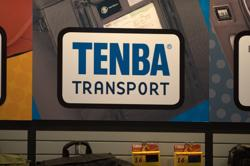
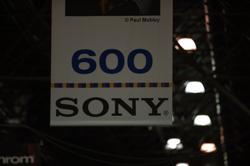
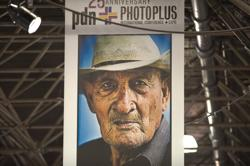
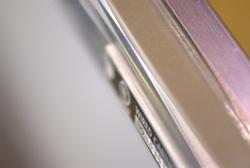
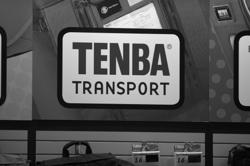
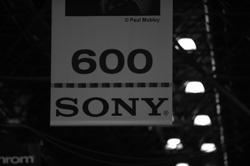
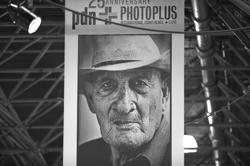
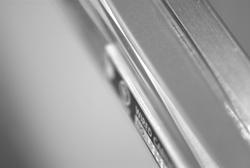
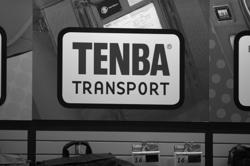
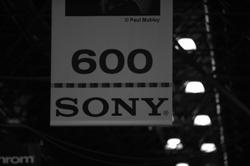
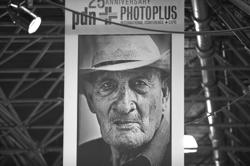
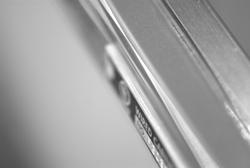
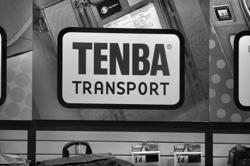
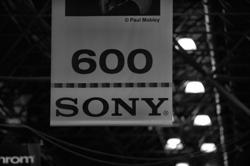
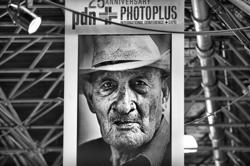
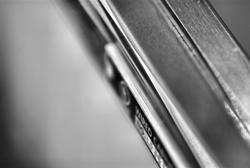

In [19]:
# The output images
pipeline.images

**Notice:** The updated metadata now includes information extracted from the image EXIF data.

In [21]:
pipeline.metadata

,ID,image-filename,flag,ImageWidth,ImageLength,BitsPerSample,Compression,DateTimeOriginal,PhotometricInterpretation,Make,...,YResolution,PlanarConfiguration,GPSInfo,ResolutionUnit,Software,DateTime,SubIFDs,ExifOffset,NewSubfileType,num_channels
0,0,DSC5606.NEF,0,160,120,"(8, 8, 8)",1,2008:10:24 09:12:54,2,NIKON CORPORATION,...,300.0,1,176628,2,Ver.1.00,2008:10:24 09:12:54,"(176648, 176768)",480,1,1
1,1,DSC5607.NEF,0,160,120,"(8, 8, 8)",1,2008:10:24 09:12:56,2,NIKON CORPORATION,...,300.0,1,187068,2,Ver.1.00,2008:10:24 09:12:56,"(187088, 187208)",480,1,1
2,2,DSC5608.NEF,0,160,120,"(8, 8, 8)",1,2008:10:24 09:12:58,2,NIKON CORPORATION,...,300.0,1,174582,2,Ver.1.00,2008:10:24 09:12:58,"(174600, 174720)",480,1,1
3,3,DSC_0001.NEF,0,160,120,"(8, 8, 8)",1,2008:10:23 13:07:17,2,NIKON CORPORATION,...,300.0,1,160708,2,Ver.1.00,2008:10:23 13:07:17,"(160728, 160848)",480,1,1


## Working with other RAW images (non specified format)

When images can’t be read using `opencv`, `Pillow`, or `rawpy`, you’ll need to load them manually by specifying the size, bit depth, and color encoding.

### This is the configuration file:


```yaml
general:
  sample_data: "benthic_raw_images"
  output_path: "./output"
  n_jobs: 4

steps:
  - colour:
      name: "grayscale"
      mode: "grayscale"

  - colour:
      name: "colour_correction"
      mode: "gaussian_blur"
      params:
        sigma: 1.0

  - colour:
      name: "contrast"
      mode: "contrast"
```

This dataset is related to benthic research and includes a small image collection with corresponding metadata.

### Instantiate the pipeline class

In [22]:
pipeline = Pipeline(config_file_path="../config_files/config_raw_images.yml")

☁ paidiverpy ☁  |    WARNING | 2025-05-19 15:43:27 | Metadata does not have a datetime type column. It should have one of the following columns: ['datetime', 'date_time', 'DateTime', 'Datetime', 'image-datetime']. 

☁ paidiverpy ☁  |    WARNING | 2025-05-19 15:43:27 | Metadata does not have a camera-position type column. It should have one of the following columns: ['camera-position', 'camera_position', 'altitude_m', 'altitude_metre', 'altitude_meters', 'altitude_meter', 'image-altitude-meters']. 

☁ paidiverpy ☁  |    WARNING | 2025-05-19 15:43:27 | Metadata does not have a depth type column. It should have one of the following columns: ['depth', 'depth_m', 'depth_metres', 'depth_metre', 'depth_meters', 'depth_meter', 'image-depth']. 

☁ paidiverpy ☁  |    WARNING | 2025-05-19 15:43:27 | Metadata does not have a lat type column. It should have one of the following columns: ['lat', 'latitude_deg', 'latitude', 'Latitude', 'Latitude_deg', 'Lat', 'image-latitude']. 

☁ paidiverpy ☁  |    

*As before, any metadata warnings can be safely ignored.*

### Updated Configuration After Download

In [23]:
pipeline.config

{
    "general": {
        "name": "raw",
        "step_name": "open",
        "sample_data": "benthic_raw_images",
        "input_path": "/home/tobfer/.paidiverpy_cache/benthic_raw_images/images",
        "metadata_path": "/home/tobfer/.paidiverpy_cache/benthic_raw_images/metadata/metadata_benthic_raw_images.csv",
        "metadata_type": "CSV_FILE",
        "image_open_args": {
            "image_type": "raw",
            "params": {
                "width": 2448,
                "height": 2048,
                "bit_depth": 8,
                "endianness": null,
                "layout": null,
                "image_misc": "bayer",
                "bayer_pattern": "GB",
                "file_header_size": 0
            }
        },
        "is_remote": false,
        "output_is_remote": false,
        "output_path": "output",
        "n_jobs": 1,
        "track_changes": true
    },
    "steps": [
        {
            "name": "grayscale",
            "step_name": "colour",
         

Here’s the corresponding `image_open_args` for manually loading unsupported raw files:

```json
"image_open_args": {
    "image_type": "raw",
    "params": {
        "width": 2448,
        "height": 2048,
        "bit_depth": 8,
        "endianness": null,
        "layout": null,
        "image_misc": "bayer",
        "bayer_pattern": "GB",
        "file_header_size": 0
    }
}
```

Since `Rawpy` doesn't support these images, the system will detect this and switch to manual loading.

The `params` field provides essential information needed to decode the image. These options are inspired by those available in [IrfanView](https://www.irfanview.com), a widely used Windows program for handling raw image formats.

For detailed documentation on accepted parameters, refer to the [Paidiverpy Image Formats Guide](https://paidiverpy.readthedocs.io/en/latest/guide/image_formats/index.html).

👉 **Tip**: As with `.NEF` files, start with a basic configuration and a few sample images. Test the output and refine the parameters as needed.

In [24]:
# This is the metadata
pipeline.metadata

,ID,image-filename,flag
0,0,AS5M098_ASEA_1_Camera_13331848_13354729087593.raw,0
1,1,AS5M098_ASEA_1_Camera_13331848_13354729088593.raw,0
2,2,AS5M098_ASEA_1_Camera_13331848_13354729089593.raw,0
3,3,AS5M098_ASEA_1_Camera_13331848_13354729090593.raw,0
4,4,AS5M098_ASEA_1_Camera_13331848_13354729091593.raw,0
5,5,AS5M098_ASEA_1_Camera_13331848_13354729092593.raw,0
6,6,AS5M098_ASEA_1_Camera_13331848_13354729093593.raw,0
7,7,AS5M098_ASEA_1_Camera_13331848_13354729094593.raw,0
8,8,AS5M098_ASEA_1_Camera_13331848_13354729095593.raw,0
9,9,AS5M098_ASEA_1_Camera_13331848_13354729096593.raw,0


In [25]:
pipeline.run()

☁ paidiverpy ☁  |       INFO | 2025-05-19 15:43:30 | Processing images using 1 cores
☁ paidiverpy ☁  |       INFO | 2025-05-19 15:43:30 | Running step 0: raw - OpenLayer


Open Images: 100%|█████████████████████████████████| 12/12 [00:00<00:00, 170.73it/s]


☁ paidiverpy ☁  |       INFO | 2025-05-19 15:43:30 | Step 0 completed


INFO:paidiverpy:Step 0 completed


☁ paidiverpy ☁  |       INFO | 2025-05-19 15:43:30 | Running step 1: grayscale - ColourLayer


...


INFO:paidiverpy:Step 2 completed


☁ paidiverpy ☁  |       INFO | 2025-05-19 15:43:30 | Running step 3: contrast - ColourLayer


INFO:paidiverpy:Running step 3: contrast - ColourLayer
Processing images: 100%|████████████████████████████| 12/12 [00:04<00:00,  2.90it/s]

☁ paidiverpy ☁  |       INFO | 2025-05-19 15:43:35 | Step 3 completed



INFO:paidiverpy:Step 3 completed


Step: raw
Image: [[[12 16 14]
  [12 16 14]
  [12 16 13]
  ...
  [11 14 13]
  [10 13 13]
  [10 13 13]]

 [[12 16 14]
  [12 16 14]
  [12 16 13]
  ...
  [11 14 13]
  [10 13 13]
  [10 13 13]]

 [[13 15 15]
  [13 15 15]
  [12 16 13]
  ...
  [11 13 13]
  [10 12 13]
  [10 12 13]]

 ...

 [[20 23 28]
  [20 23 28]
  [19 28 25]
  ...
  [16 20 24]
  [15 20 22]
  [15 20 22]]

 [[19 27 27]
  [19 27 27]
  [19 29 27]
  ...
  [16 21 23]
  [15 20 21]
  [15 20 21]]

 [[19 27 27]
  [19 27 27]
  [19 29 27]
  ...
  [16 21 23]
  [15 20 21]
  [15 20 21]]]
Image: [[[11 13 12]
  [11 13 12]
  [11 14 13]
  ...
  [12 14 13]
  [12 14 14]
  [12 14 14]]

 [[11 13 12]
  [11 13 12]
  [11 14 13]
  ...
  [12 14 13]
  [12 14 14]
  [12 14 14]]

 [[11 14 11]
  [11 14 11]
  [11 15 12]
  ...
  [12 14 13]
  [12 14 14]
  [12 14 14]]

 ...

 [[18 26 31]
  [18 26 31]
  [18 26 30]
  ...
  [12 14 18]
  [12 15 19]
  [12 15 19]]

 [[17 27 29]
  [17 27 29]
  [18 27 28]
  ...
  [12 16 18]
  [13 15 18]
  [13 15 18]]

 [[17 27 29]
  [17 27 29]
  [18 27 28]
  ...
  [12 16 18]
  [13 15 18]
  [13 15 18]]]
Image: [[[12 14 14]
  [12 14 14]
  [12 15 13]
  ...
  [10 15 16]
  [11 15 16]
  [11 15 16]]

 [[12 14 14]
  [12 14 14]
  [12 15 13]
  ...
  [10 15 16]
  [11 15 16]
  [11 15 16]]

 [[12 15 14]
  [12 15 14]
  [12 15 12]
  ...
  [11 15 16]
  [12 16 17]
  [12 16 17]]

 ...

 [[17 17 22]
  [17 17 22]
  [16 19 20]
  ...
  [14 22 27]
  [15 21 26]
  [15 21 26]]

 [[16 18 21]
  [16 18 21]
  [16 18 21]
  ...
  [14 21 26]
  [15 21 26]
  [15 21 26]]

 [[16 18 21]
  [16 18 21]
  [16 18 21]
  ...
  [14 21 26]
  [15 21 26]
  [15 21 26]]]
Image: [[[13 18 20]
  [13 18 20]
  [13 18 19]
  ...
  [ 9 12 16]
  [10 14 16]
  [10 14 16]]

 [[13 18 20]
  [13 18 20]
  [13 18 19]
  ...
  [ 9 12 16]
  [10 14 16]
  [10 14 16]]

 [[13 19 18]
  [13 19 18]
  [13 20 17]
  ...
  [ 9 14 17]
  [10 14 15]
  [10 14 15]]

 ...

 [[15 21 20]
  [15 21 20]
  [16 20 20]
  ...
  [14 21 24]
  [15 21 25]
  [15 21 25]]

 [[15 21 21]
  [15 21 21]
  [16 20 21]
  ...
  [14 20 23]
  [15 21 24]
  [15 21 24]]

 [[15 21 21]
  [15 21 21]
  [16 20 21]
  ...
  [14 20 23]
  [15 21 24]
  [15 21 24]]]
Image: [[[11 16 22]
  [11 16 22]
  [11 17 21]
  ...
  [12 14 11]
  [11 14 12]
  [11 14 12]]

 [[11 16 22]
  [11 16 22]
  [11 17 21]
  ...
  [12 14 11]
  [11 14 12]
  [11 14 12]]

 [[11 16 19]
  [11 16 19]
  [12 17 20]
  ...
  [13 14 10]
  [12 14 12]
  [12 14 12]]

 ...

 [[18 23 27]
  [18 23 27]
  [18 24 27]
  ...
  [15 19 25]
  [16 20 24]
  [16 20 24]]

 [[19 23 29]
  [19 23 29]
  [18 23 28]
  ...
  [14 19 24]
  [15 18 25]
  [15 18 25]]

 [[19 23 29]
  [19 23 29]
  [18 23 28]
  ...
  [14 19 24]
  [15 18 25]
  [15 18 25]]]
Image: [[[11 16 17]
  [11 16 17]
  [12 16 19]
  ...
  [11 17 18]
  [11 16 19]
  [11 16 19]]

 [[11 16 17]
  [11 16 17]
  [12 16 19]
  ...
  [11 17 18]
  [11 16 19]
  [11 16 19]]

 [[11 17 17]
  [11 17 17]
  [12 17 19]
  ...
  [12 16 17]
  [12 15 18]
  [12 15 18]]

 ...

 [[18 24 29]
  [18 24 29]
  [18 23 27]
  ...
  [18 23 27]
  [17 24 26]
  [17 24 26]]

 [[16 23 28]
  [16 23 28]
  [17 24 26]
  ...
  [19 23 24]
  [19 23 24]
  [19 23 24]]

 [[16 23 28]
  [16 23 28]
  [17 24 26]
  ...
  [19 23 24]
  [19 23 24]
  [19 23 24]]]
Image: [[[12 18 17]
  [12 18 17]
  [12 17 16]
  ...
  [12 16 15]
  [14 15 15]
  [14 15 15]]

 [[12 18 17]
  [12 18 17]
  [12 17 16]
  ...
  [12 16 15]
  [14 15 15]
  [14 15 15]]

 [[11 17 17]
  [11 17 17]
  [12 16 16]
  ...
  [14 16 16]
  [14 14 15]
  [14 14 15]]

 ...

 [[16 24 24]
  [16 24 24]
  [16 26 23]
  ...
  [16 22 27]
  [16 20 30]
  [16 20 30]]

 [[15 24 27]
  [15 24 27]
  [16 26 27]
  ...
  [15 21 24]
  [17 20 26]
  [17 20 26]]

 [[15 24 27]
  [15 24 27]
  [16 26 27]
  ...
  [15 21 24]
  [17 20 26]
  [17 20 26]]]
Image: [[[14 17 15]
  [14 17 15]
  [14 17 12]
  ...
  [11 15 17]
  [11 16 18]
  [11 16 18]]

 [[14 17 15]
  [14 17 15]
  [14 17 12]
  ...
  [11 15 17]
  [11 16 18]
  [11 16 18]]

 [[13 17 16]
  [13 17 16]
  [13 17 15]
  ...
  [11 16 17]
  [11 16 19]
  [11 16 19]]

 ...

 [[18 22 24]
  [
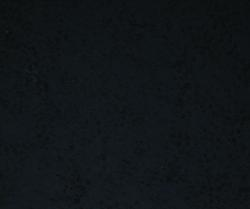
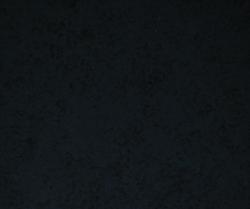
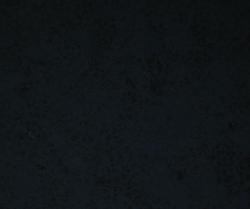
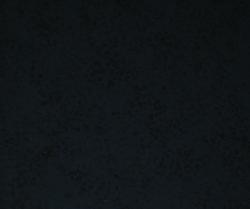
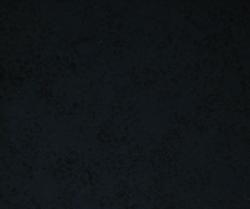
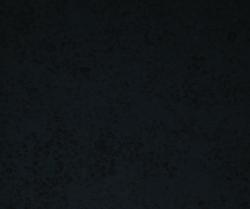
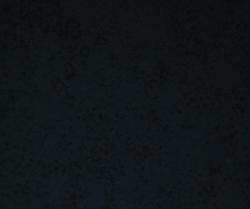
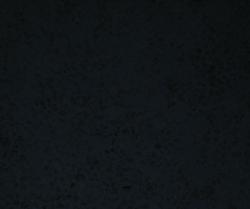
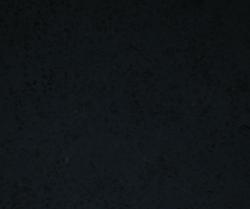
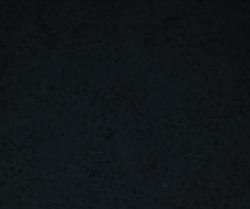
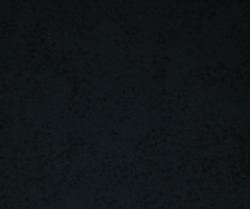
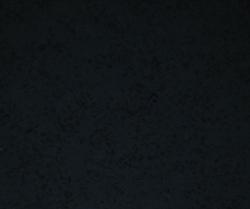
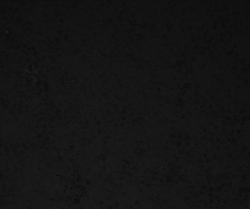
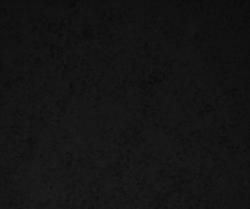
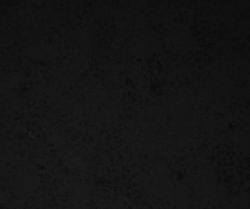
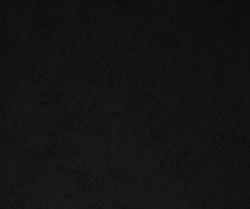
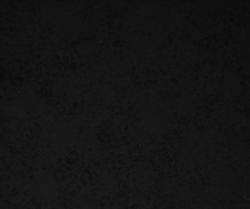
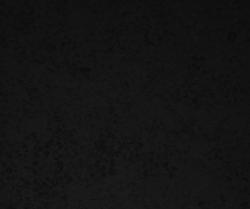
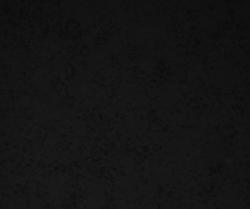
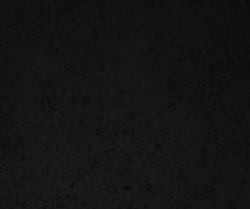
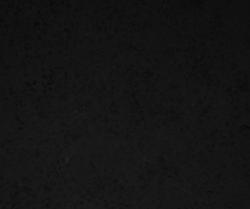
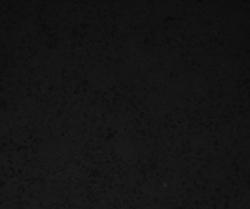
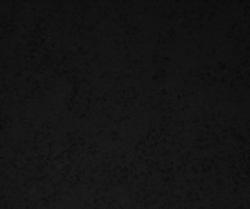
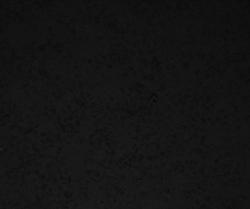
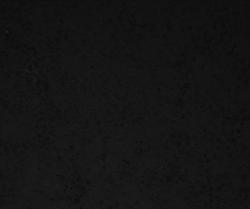
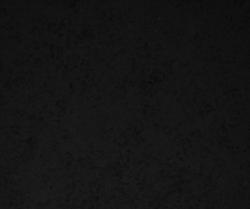
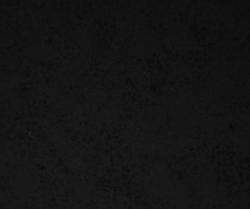
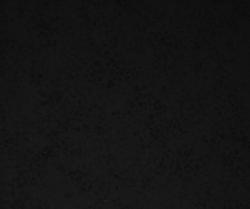
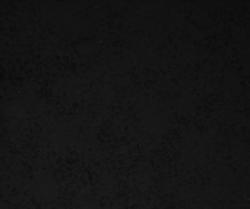
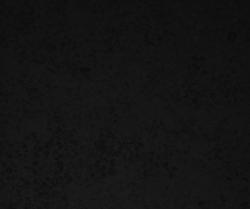
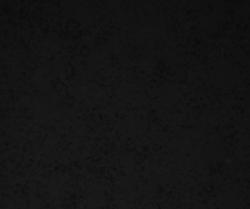
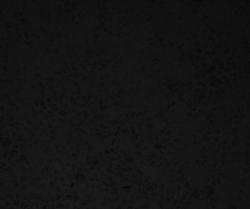
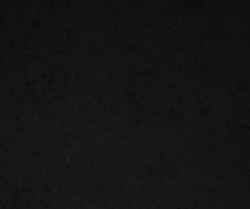
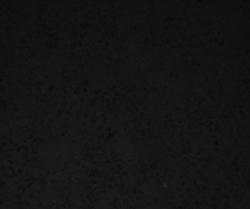
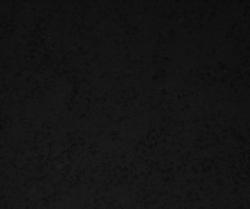
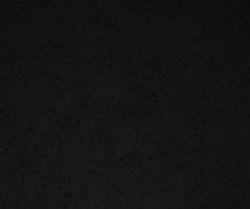
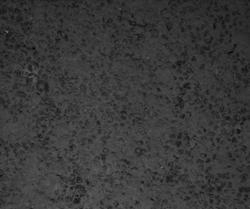
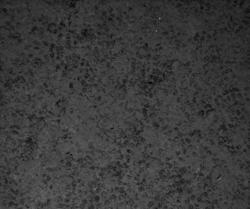
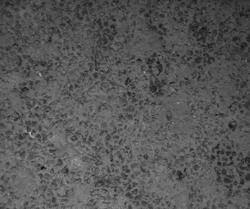
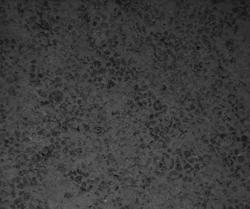
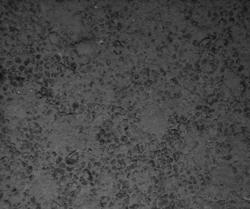
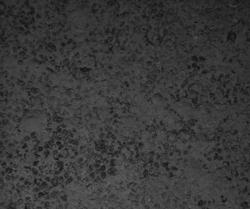
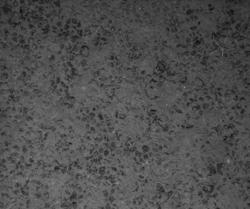
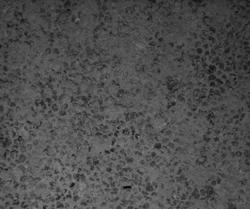
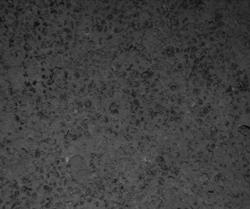
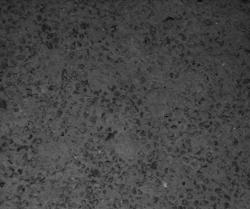
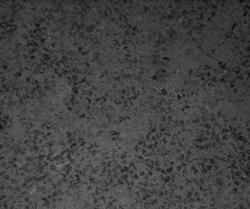
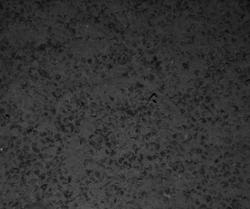

In [26]:
pipeline.images